# Singular Value Decomposition: One Factorization, Many Applications

The **Singular Value Decomposition** is arguably the most important matrix factorization in all of applied mathematics. It takes *any* real matrix — square or rectangular, full-rank or rank-deficient, dense or sparse — and writes it as the product of three simple pieces: a rotation, a diagonal stretch, and another rotation. That single trick unlocks PCA, image and video compression, recommender systems, latent semantic analysis, the stable numerical computation of pseudo-inverses and least-squares solutions, and a large chunk of modern signal processing.

In this notebook we build up SVD from the math, then put it to work on **three** separate applications, each highlighting a different face of the decomposition:

1. **Image compression** — the iconic Eckart-Young-Mirsky demonstration: keep the top $k$ singular triplets and watch a large matrix of pixels shrink while the picture stays recognisable.
2. **PCA is SVD in disguise** — a quick numerical proof that our [`PrincipalComponentAnalysis`](../../../src/mlpackage/unsupervised_learning/pca.py) class returns exactly what you get by running `np.linalg.svd` on the centred data matrix.
3. **A collaborative-filtering recommender** — the Simon Funk / Netflix Prize-era idea: factor a sparse user-item rating matrix into low-rank latent user and item embeddings, and use that to predict unseen ratings.

## The decomposition at a glance

```mermaid
flowchart LR
    A["Matrix A (m by n)<br/>could be:<br/>image pixels,<br/>user-item ratings,<br/>data matrix..."] --> svd["np.linalg.svd(A)"]
    svd --> U["U (m by m)<br/>orthonormal<br/>left singular vectors"]
    svd --> S["Sigma<br/>sorted singular values<br/>sigma_1 >= sigma_2 >= ... >= 0"]
    svd --> Vt["V^T (n by n)<br/>orthonormal<br/>right singular vectors"]
    U --> app{"Truncate to rank k,<br/>discard sigma_k+1..."}
    S --> app
    Vt --> app
    app --> compress["Rank-k approximation<br/>A_k = sum_i=1..k sigma_i u_i v_i^T"]
    compress --> ek["Eckart-Young-Mirsky:<br/>best rank-k approx<br/>in Frobenius + spectral norm"]
```

That final box is where the practical power comes from. The best $k$-rank approximation of a matrix — in the sense of minimising reconstruction error — is always the one you get by keeping only the top $k$ singular triplets.

## The mathematics

Let $A \in \mathbb{R}^{m \times n}$ be any real matrix. The **full SVD** is

$$
A \;=\; U \Sigma V^{\top},
$$

with

- $U \in \mathbb{R}^{m \times m}$ orthogonal (columns are the **left singular vectors** $u_1, \ldots, u_m$),
- $\Sigma \in \mathbb{R}^{m \times n}$ diagonal with non-negative entries $\sigma_1 \ge \sigma_2 \ge \cdots \ge \sigma_{\min(m,n)} \ge 0$ (the **singular values**),
- $V \in \mathbb{R}^{n \times n}$ orthogonal (columns are the **right singular vectors** $v_1, \ldots, v_n$).

### Singular triplets

Pairing a column of $U$, a singular value, and a column of $V$ gives the fundamental relationships

$$
A v_i \;=\; \sigma_i u_i, \qquad A^{\top} u_i \;=\; \sigma_i v_i.
$$

So $v_i$ is a direction in input space that, after the linear map $A$, becomes $\sigma_i u_i$ — a direction in output space, scaled by the singular value. Geometry of any linear map: **rotate to line up with the $v_i$ axes, stretch along those axes by $\sigma_i$, rotate again to line up with the $u_i$ axes.**

### The thin SVD

When $m \ne n$, the columns of $U$ and $V$ beyond rank $r = \min(m, n)$ contribute nothing — their singular values are zero. It is much cheaper to compute the **thin SVD**

$$
A \;=\; U_r \, \Sigma_r \, V_r^{\top},
\qquad U_r \in \mathbb{R}^{m \times r}, \quad \Sigma_r \in \mathbb{R}^{r \times r}, \quad V_r \in \mathbb{R}^{n \times r}.
$$

`np.linalg.svd(A, full_matrices=False)` returns exactly this form.

### Low-rank truncation and Eckart-Young-Mirsky

Keep only the top $k$ singular triplets:

$$
A_k \;=\; \sum_{i=1}^{k} \sigma_i \, u_i v_i^{\top} \;=\; U_{:,\,:k} \, \Sigma_{:k,:k} \, V_{:,\,:k}^{\top}.
$$

The theorem that makes SVD a workhorse for approximation says that **no matrix of rank at most $k$ gets closer to $A$ than $A_k$ does**, whether distance is measured in Frobenius norm or spectral norm. The residual has a clean closed form:

$$
\lVert A - A_k \rVert_F^2 \;=\; \sum_{j = k+1}^{r} \sigma_j^2,
\qquad
\lVert A - A_k \rVert_2 \;=\; \sigma_{k+1}.
$$

The first identity tells us the reconstruction error *in advance* — we don't need to compute the reconstruction, only look at the tail sum of singular values.

### The PCA connection

If $X_c \in \mathbb{R}^{n \times d}$ is a centred data matrix and we let $X_c = U \Sigma V^{\top}$, then the sample covariance is

$$
S \;=\; \frac{1}{n-1} X_c^{\top} X_c \;=\; V \,\frac{\Sigma^2}{n-1}\, V^{\top}.
$$

So the right singular vectors $v_j$ **are** the principal components and the squared singular values divided by $n-1$ **are** the PCA eigenvalues. Running SVD on centred data is literally the same calculation as running PCA — and in fact this is how every numerically-serious PCA routine is implemented, because forming $X_c^{\top} X_c$ directly squares the condition number and loses precision.

## About our implementation

Unlike the DBSCAN, K-means, Label Propagation, and PCA notebooks in this folder, **we deliberately do not ship a hand-written SVD class in `mlpackage`**. The reason is practical: `np.linalg.svd` calls the LAPACK routines `gesdd`/`gesvd`, which are the same numerical kernels that scikit-learn, MATLAB, and every serious PCA or least-squares implementation uses under the hood. Writing our own would either reproduce them (pointlessly) or be measurably worse. Instead, this notebook:

- Uses `np.linalg.svd` directly for the matrix factorisation.
- Builds every application (compression, PCA check, recommender) **on top of** that call, showing how the raw decomposition becomes a useful algorithm.
- Cross-references the SVD output against our `PrincipalComponentAnalysis` class from the sibling [PCA notebook](../PCA/pca_from_scratch.ipynb), confirming that the two routes produce identical answers.

With the theory and the ground rules set, let's start compressing an image.

## Application 1: Low-rank image compression

A grayscale image is a matrix: rows and columns of pixel intensities. Natural images have lots of **redundancy** — neighbouring pixels are correlated, large regions are nearly uniform, edges repeat at similar orientations — so the matrix is effectively low-rank even though it might be formally full-rank. SVD lets us exploit this by keeping only the top $k$ singular triplets.

The storage cost of the rank-$k$ reconstruction is

$$
\underbrace{m \cdot k}_{U_k} \;+\; \underbrace{k}_{\Sigma_k \;(\text{diagonal})} \;+\; \underbrace{k \cdot n}_{V_k^{\top}} \;=\; k\,(m + n + 1),
$$

compared with $m \cdot n$ for the original image. When $k \ll \min(m,n)$ this is a big saving.

We'll use scikit-learn's bundled sample image `china.jpg` (a photograph of the Great Wall, 427 x 640 in colour) — no download is required since sklearn ships it inside the package. We convert to grayscale so we have a single matrix to factor, and then watch what happens as we reconstruct at ranks 1, 5, 10, 25, 50, 100, 200, and full.

Image shape (grayscale):   (427, 640)   dtype = float64
Pixel range:               [0.000, 1.000]
Total pixels (=storage):   273280


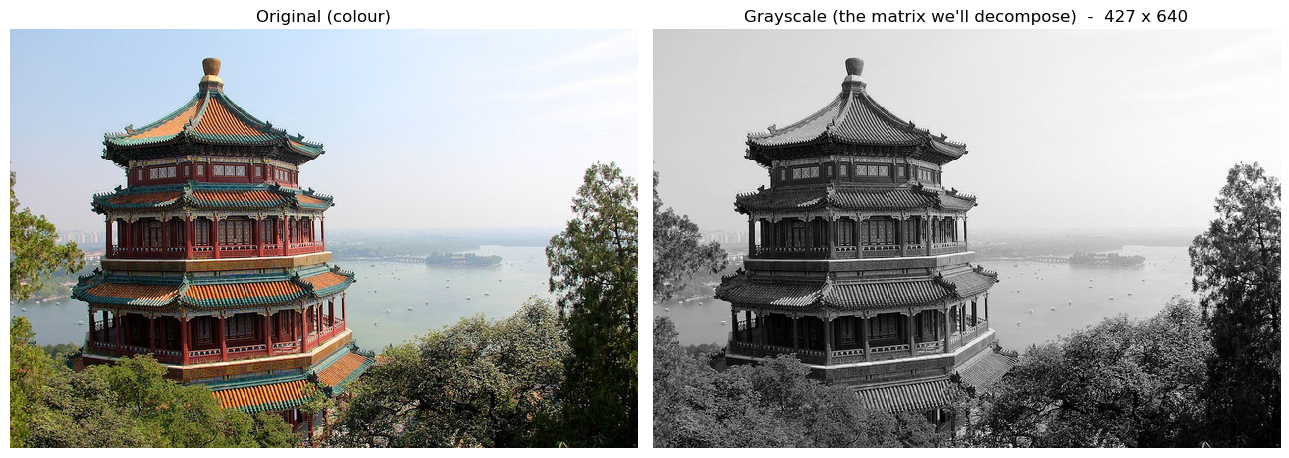

In [1]:
import sys
from pathlib import Path

_here = Path.cwd()
while _here != _here.parent and not (_here / "pyproject.toml").exists():
    _here = _here.parent
REPO_ROOT = _here
sys.path.insert(0, str(REPO_ROOT / "src"))

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_sample_image

plt.rcParams.update({"figure.figsize": (8, 5), "axes.grid": True, "grid.alpha": 0.3})

img_rgb = load_sample_image("china.jpg")
img_rgb = img_rgb.astype(np.float64) / 255.0
A = img_rgb.mean(axis=2)
m, n = A.shape
print(f"Image shape (grayscale):   {A.shape}   dtype = {A.dtype}")
print(f"Pixel range:               [{A.min():.3f}, {A.max():.3f}]")
print(f"Total pixels (=storage):   {A.size}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].imshow(img_rgb, interpolation="nearest")
axes[0].set_title("Original (colour)")
axes[0].axis("off")
axes[1].imshow(A, cmap="gray", interpolation="nearest")
axes[1].set_title(f"Grayscale (the matrix we'll decompose)  -  {m} x {n}")
axes[1].axis("off")
plt.tight_layout()
plt.show()

Thin SVD computed in 0.37s
U shape:    (427, 427)   (m x r)
sigma shape:(427,)     (r,)
V^T shape:  (427, 640)    (r x n)
Rank r = min(m, n) = 427
Smallest k retaining >= 90% of energy:   k = 1
Smallest k retaining >= 95% of energy:   k = 3
Smallest k retaining >= 99% of energy:   k = 54


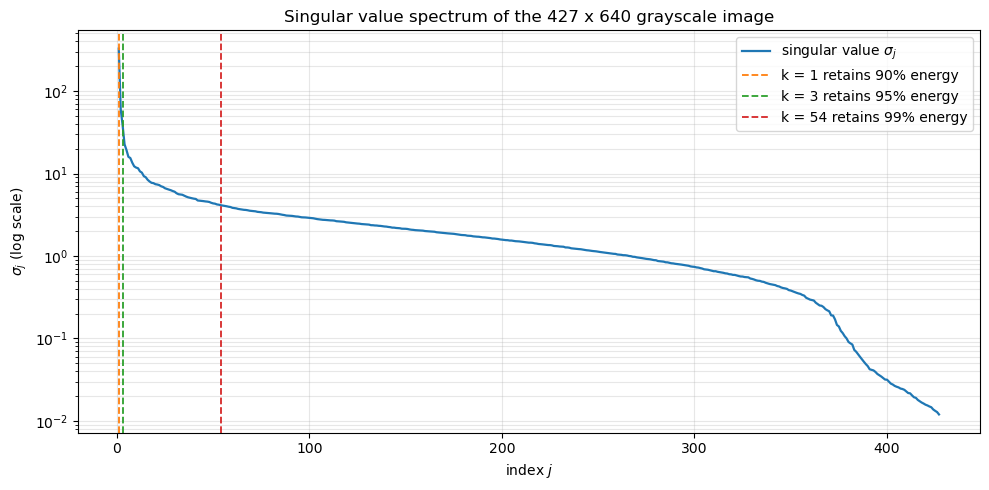

In [2]:
import time

t0 = time.time()
U, sigmas, Vt = np.linalg.svd(A, full_matrices=False)
svd_time = time.time() - t0

r = len(sigmas)
print(f"Thin SVD computed in {svd_time:.2f}s")
print(f"U shape:    {U.shape}   (m x r)")
print(f"sigma shape:{sigmas.shape}     (r,)")
print(f"V^T shape:  {Vt.shape}    (r x n)")
print(f"Rank r = min(m, n) = {r}")

cum_energy = np.cumsum(sigmas ** 2) / np.sum(sigmas ** 2)
thresholds = [0.90, 0.95, 0.99]
k_for = {t: int(np.searchsorted(cum_energy, t) + 1) for t in thresholds}
for t in thresholds:
    print(f"Smallest k retaining >= {t:.0%} of energy:   k = {k_for[t]}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogy(np.arange(1, len(sigmas) + 1), sigmas, linewidth=1.6, color="tab:blue", label="singular value $\\sigma_j$")
colors = ["tab:orange", "tab:green", "tab:red"]
for t, colour in zip(thresholds, colors):
    ax.axvline(k_for[t], color=colour, linestyle="--", linewidth=1.3,
               label=f"k = {k_for[t]} retains {t:.0%} energy")
ax.set_xlabel("index $j$")
ax.set_ylabel("$\\sigma_j$ (log scale)")
ax.set_title(f"Singular value spectrum of the {m} x {n} grayscale image")
ax.grid(True, which="both", alpha=0.3)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

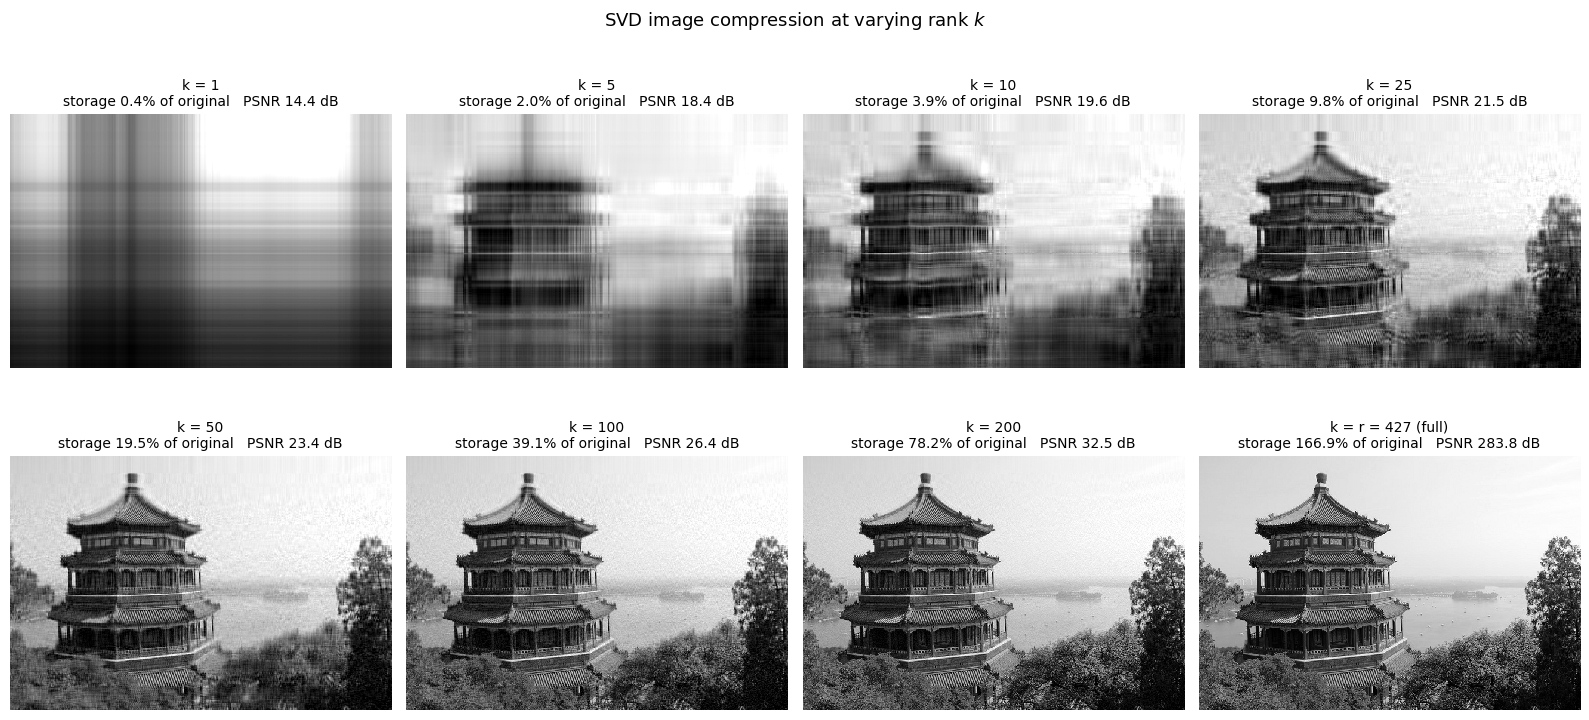

In [3]:
def reconstruct(U, sigmas, Vt, k):
    return U[:, :k] * sigmas[:k] @ Vt[:k, :]

def psnr(original, reconstruction, data_range=1.0):
    mse = np.mean((original - reconstruction) ** 2)
    if mse == 0:
        return np.inf
    return 10.0 * np.log10(data_range ** 2 / mse)

ks_demo = [1, 5, 10, 25, 50, 100, 200, r]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, k in zip(axes.ravel(), ks_demo):
    A_k = reconstruct(U, sigmas, Vt, k)
    storage = k * (m + n + 1)
    ratio = storage / A.size
    p = psnr(A, A_k, data_range=1.0)
    ax.imshow(np.clip(A_k, 0, 1), cmap="gray", interpolation="nearest")
    label_k = f"k = {k}" if k < r else f"k = r = {r} (full)"
    ax.set_title(f"{label_k}\nstorage {ratio:.1%} of original   PSNR {p:.1f} dB", fontsize=10)
    ax.axis("off")

fig.suptitle("SVD image compression at varying rank $k$", fontsize=13)
plt.tight_layout()
plt.show()

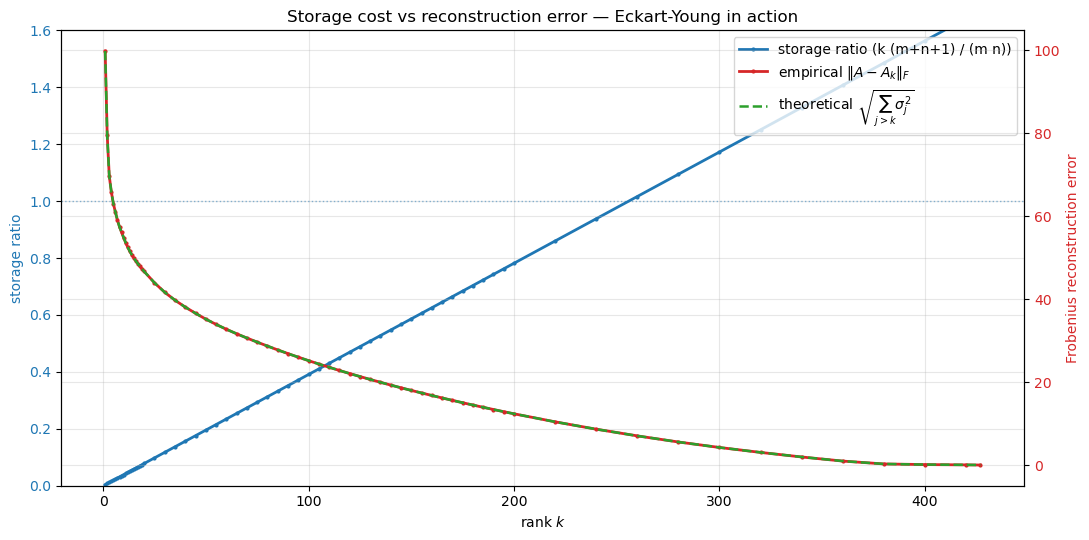

Max |empirical error - theoretical prediction| across the sweep: 3.39e-12
(The two curves should be identical to floating-point precision -- this verifies the theorem numerically.)


In [4]:
ks_sweep = np.unique(np.concatenate([
    np.arange(1, 21),
    np.arange(25, 201, 5),
    np.arange(200, r + 1, 20),
    [r],
])).astype(int)

ratios = ks_sweep * (m + n + 1) / A.size
errors_empirical = np.array([np.linalg.norm(A - reconstruct(U, sigmas, Vt, int(k)), "fro") for k in ks_sweep])
errors_theory = np.array([np.sqrt(np.sum(sigmas[int(k):] ** 2)) for k in ks_sweep])

fig, ax_left = plt.subplots(figsize=(11, 5.5))
ax_right = ax_left.twinx()

line1, = ax_left.plot(ks_sweep, ratios, color="tab:blue", marker=".", markersize=4, linewidth=2,
                      label="storage ratio (k (m+n+1) / (m n))")
ax_left.axhline(1.0, color="tab:blue", linestyle=":", linewidth=1, alpha=0.5)
ax_left.set_xlabel("rank $k$")
ax_left.set_ylabel("storage ratio", color="tab:blue")
ax_left.tick_params(axis="y", labelcolor="tab:blue")
ax_left.set_ylim(0, 1.6)

line2, = ax_right.plot(ks_sweep, errors_empirical, color="tab:red", marker=".", markersize=4, linewidth=2,
                       label="empirical $\\|A - A_k\\|_F$")
line3, = ax_right.plot(ks_sweep, errors_theory, color="tab:green", linestyle="--", linewidth=1.8,
                       label=r"theoretical $\sqrt{\sum_{j>k}\sigma_j^2}$")
ax_right.set_ylabel("Frobenius reconstruction error", color="tab:red")
ax_right.tick_params(axis="y", labelcolor="tab:red")

ax_left.legend(handles=[line1, line2, line3], loc="upper right")
ax_left.set_title("Storage cost vs reconstruction error — Eckart-Young in action")
ax_left.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

max_abs_diff = np.max(np.abs(errors_empirical - errors_theory))
print(f"Max |empirical error - theoretical prediction| across the sweep: {max_abs_diff:.2e}")
print("(The two curves should be identical to floating-point precision -- this verifies the theorem numerically.)")

## Application 2: PCA is SVD in disguise

The math section above derived the identity

$$
S \;=\; \frac{1}{n-1} X_c^{\top} X_c \;=\; V \, \frac{\Sigma^2}{n-1} \, V^{\top}
\qquad\Longleftrightarrow\qquad
\lambda_j \;=\; \frac{\sigma_j^2}{n-1},
\quad v_j^{(\text{PCA})} \;=\; v_j^{(\text{SVD of } X_c)}.
$$

Below we confirm this numerically on a small tabular dataset (the classic Iris data — 150 samples, 4 features, 3 classes). We run PCA through **two completely independent code paths**:

1. Our [`PrincipalComponentAnalysis`](../../../src/mlpackage/unsupervised_learning/pca.py) class, which calls `np.linalg.eigh` on the covariance matrix.
2. `np.linalg.svd` on the centred data matrix, with the algebraic translation applied.

If the SVD-PCA equivalence holds, the eigenvalues should agree to floating-point precision and the axes should be identical up to sign flips (as always with PCA). Any discrepancy would mean either our class has a bug or the theorem is wrong — and the theorem is 100 years old, so...

In [5]:
from sklearn.datasets import load_iris
from mlpackage.unsupervised_learning import PrincipalComponentAnalysis

iris = load_iris()
X_iris = iris.data
y_iris = iris.target
n_iris, d_iris = X_iris.shape
print(f"Iris dataset: {n_iris} samples, {d_iris} features ({iris.feature_names})")

# --- Path 1: our PrincipalComponentAnalysis class (covariance + eigh) ---
pca = PrincipalComponentAnalysis().fit(X_iris)
lambdas_pca = pca.eigenvalues_
V_pca = pca.axes_

# --- Path 2: np.linalg.svd on centred data ---
mu = X_iris.mean(axis=0)
X_c = X_iris - mu
U_iris, sig_iris, Vt_iris = np.linalg.svd(X_c, full_matrices=False)
lambdas_svd = sig_iris ** 2 / (n_iris - 1)
V_svd = Vt_iris

print("\n-------- Eigenvalue / variance comparison --------")
print(f"{'j':>3s} | {'PCA lambda_j':>14s} | {'sigma_j^2/(n-1)':>16s} | {'diff':>10s}")
for j in range(d_iris):
    diff = abs(lambdas_pca[j] - lambdas_svd[j])
    print(f"{j+1:>3d} | {lambdas_pca[j]:>14.6f} | {lambdas_svd[j]:>16.6f} | {diff:>10.2e}")
print(f"\nMax |difference|: {np.max(np.abs(lambdas_pca - lambdas_svd)):.2e}")

print("\n-------- Axes: per-axis |cos(our, SVD)| (should be ~= 1) --------")
abs_cos = np.abs(np.sum(V_pca * V_svd, axis=1))
for j, c in enumerate(abs_cos):
    sign = "+" if np.sum(V_pca[j] * V_svd[j]) > 0 else "-"
    print(f"axis {j+1}: |cos| = {c:.10f}   (relative sign = {sign})")

print("\nConclusion: PCA and SVD-of-centred-data produce the same decomposition,")
print("up to the expected sign flips in individual eigenvectors.")

Iris dataset: 150 samples, 4 features (['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)'])

-------- Eigenvalue / variance comparison --------
  j |   PCA lambda_j |  sigma_j^2/(n-1) |       diff
  1 |       4.228242 |         4.228242 |   4.44e-15
  2 |       0.242671 |         0.242671 |   5.55e-16
  3 |       0.078210 |         0.078210 |   2.78e-17
  4 |       0.023835 |         0.023835 |   1.73e-17

Max |difference|: 4.44e-15

-------- Axes: per-axis |cos(our, SVD)| (should be ~= 1) --------
axis 1: |cos| = 1.0000000000   (relative sign = -)
axis 2: |cos| = 1.0000000000   (relative sign = -)
axis 3: |cos| = 1.0000000000   (relative sign = +)
axis 4: |cos| = 1.0000000000   (relative sign = +)

Conclusion: PCA and SVD-of-centred-data produce the same decomposition,
up to the expected sign flips in individual eigenvectors.


## Application 3: A collaborative-filtering recommender

Imagine a streaming service. Each row of a rating matrix $R$ is a user; each column is a movie; entry $R_{ij}$ is the rating user $i$ gave movie $j$. Real rating matrices are **enormous and mostly empty** — a given user has rated a tiny fraction of the catalogue. The recommender problem is to fill in those empty entries: *"Given what this user has rated, what would they give to movies they haven't seen?"*

The Simon Funk / Netflix-Prize-era insight is that $R$, even after you fill in the missing entries honestly, is well-approximated by a **low-rank** matrix:

$$
R \;\approx\; P \, Q^{\top},
\qquad P \in \mathbb{R}^{n_\text{users} \times k}, \quad Q \in \mathbb{R}^{n_\text{movies} \times k}.
$$

Each user has a $k$-dimensional **latent taste vector** $P_{i,:}$, each movie has a $k$-dimensional **latent appeal vector** $Q_{j,:}$, and the predicted rating is just their dot product. A handful of latent dimensions might encode things like "action vs. drama", "arthouse vs. blockbuster", and so on — discovered automatically from the rating data, no labels required.

Truncated SVD gives exactly this factorisation. The recipe has three steps:

1. **Centre by user mean** to remove systematic per-user rating offsets (a harsh grader versus a generous one). Store the row means so we can add them back later.
2. **Fill the missing entries with 0** in the centred matrix — zero is now the "this user's typical rating" baseline, so an unknown entry contributes nothing biased.
3. **Truncated SVD at rank $k$**, then add the row means back. That gives the predicted rating for every user-movie pair.

$$
\tilde{R} = R - \mu_{\text{user}} \mathbf{1}^{\top},
\qquad
\tilde{R} \approx U_k \Sigma_k V_k^{\top},
\qquad
\hat{R} = U_k \Sigma_k V_k^{\top} + \mu_{\text{user}} \mathbf{1}^{\top}.
$$

Writing $P = U_k \Sigma_k^{1/2}$ and $Q = V_k \Sigma_k^{1/2}$ makes the latent structure explicit: $\hat{R}_{ij} - \mu_i = P_{i,:} \cdot Q_{j,:}$ is the inner product of user $i$'s taste vector with movie $j$'s appeal vector.

### A controlled experiment

To get clean, reproducible numbers we'll use a **synthetic** rating matrix with known latent rank 3: we generate two random factor matrices $P_{\text{true}}$ and $Q_{\text{true}}$, compute $R_{\text{true}} = P_{\text{true}} Q_{\text{true}}^{\top}$, add small noise, rescale to a 1-5 rating scale, and randomly hide 60% of the entries. If SVD is working correctly, the test RMSE should be minimised at **$k = 3$** — the true latent rank — and grow again for larger $k$ as the extra components start fitting noise.

Rating matrix:      50 users x 40 movies = 2000 entries
Observed entries:   793 (39.6%)
Hidden (to predict):1207 (60.3%)
Rating scale:       [1.00, 5.00]  (mimicking a 1-5 scale)


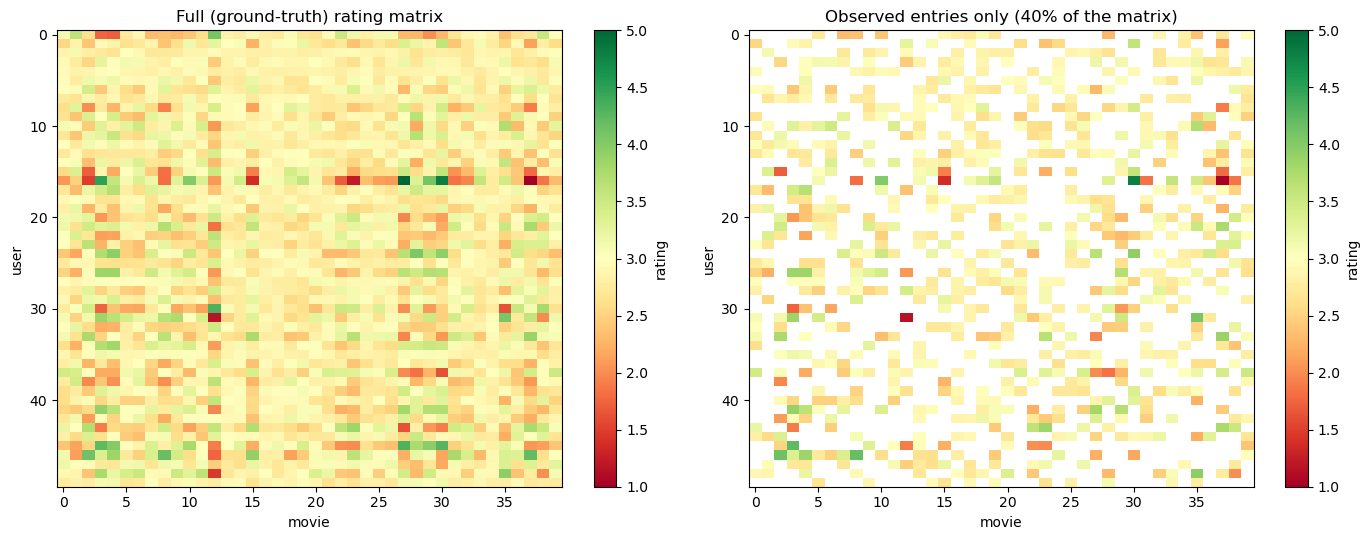

In [6]:
N_USERS, N_MOVIES, TRUE_RANK = 50, 40, 3
NOISE_STD = 0.25
OBSERVED_FRAC = 0.40

rng = np.random.default_rng(2026)

P_true = rng.normal(loc=0.0, scale=1.0, size=(N_USERS, TRUE_RANK))
Q_true = rng.normal(loc=0.0, scale=1.0, size=(N_MOVIES, TRUE_RANK))
R_signal = P_true @ Q_true.T
R_noisy = R_signal + rng.normal(scale=NOISE_STD, size=R_signal.shape)

R_min, R_max = R_noisy.min(), R_noisy.max()
R_ratings = 1.0 + 4.0 * (R_noisy - R_min) / (R_max - R_min)

observed_mask = rng.random(R_ratings.shape) < OBSERVED_FRAC
n_total = R_ratings.size
n_observed = int(observed_mask.sum())
print(f"Rating matrix:      {N_USERS} users x {N_MOVIES} movies = {n_total} entries")
print(f"Observed entries:   {n_observed} ({n_observed / n_total:.1%})")
print(f"Hidden (to predict):{n_total - n_observed} ({1 - n_observed / n_total:.1%})")
print(f"Rating scale:       [{R_ratings.min():.2f}, {R_ratings.max():.2f}]  (mimicking a 1-5 scale)")

R_display = R_ratings.copy()
R_display[~observed_mask] = np.nan

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
im0 = axes[0].imshow(R_ratings, cmap="RdYlGn", vmin=1, vmax=5, aspect="auto")
axes[0].set_title("Full (ground-truth) rating matrix")
axes[0].set_xlabel("movie")
axes[0].set_ylabel("user")
axes[0].grid(False)
fig.colorbar(im0, ax=axes[0], label="rating")

im1 = axes[1].imshow(R_display, cmap="RdYlGn", vmin=1, vmax=5, aspect="auto")
axes[1].set_title(f"Observed entries only ({OBSERVED_FRAC:.0%} of the matrix)")
axes[1].set_xlabel("movie")
axes[1].set_ylabel("user")
axes[1].grid(False)
fig.colorbar(im1, ax=axes[1], label="rating")
plt.tight_layout()
plt.show()

In [7]:
def predict_via_svd(R_obs, mask, k):
    """
    Centre by per-user mean, zero-fill unobserved entries, rank-k SVD,
    then re-add the user means. Returns the full predicted matrix.
    """
    fallback = R_obs[mask].mean()
    row_means = np.array([
        R_obs[i][mask[i]].mean() if mask[i].any() else fallback
        for i in range(R_obs.shape[0])
    ])
    R_centered = R_obs.astype(float) - row_means[:, None]
    R_centered[~mask] = 0.0

    U_r, s_r, Vt_r = np.linalg.svd(R_centered, full_matrices=False)
    R_hat_centered = U_r[:, :k] * s_r[:k] @ Vt_r[:k, :]
    return R_hat_centered + row_means[:, None]

k_demo = 3
R_hat_k3 = predict_via_svd(R_ratings, observed_mask, k=k_demo)

hidden_mask = ~observed_mask
errors_k3 = R_ratings[hidden_mask] - R_hat_k3[hidden_mask]
rmse_k3 = float(np.sqrt(np.mean(errors_k3 ** 2)))
print(f"Rank-{k_demo} predictions on the hidden entries:")
print(f"  Test RMSE = {rmse_k3:.4f}   (rating scale is 1-5)")
print(f"  Mean absolute error = {float(np.mean(np.abs(errors_k3))):.4f}")

print("\n8 random hidden user-movie pairs:")
hidden_ij = np.argwhere(hidden_mask)
sample_ij = hidden_ij[rng.choice(len(hidden_ij), size=8, replace=False)]
print(f"  {'user':>4s}  {'movie':>5s}  {'actual':>7s}  {'predicted':>10s}  {'error':>7s}")
for i, j in sample_ij:
    actual = R_ratings[i, j]
    pred = R_hat_k3[i, j]
    print(f"  {i:>4d}  {j:>5d}  {actual:>7.2f}  {pred:>10.2f}  {pred - actual:>+7.2f}")

Rank-3 predictions on the hidden entries:
  Test RMSE = 0.3218   (rating scale is 1-5)
  Mean absolute error = 0.2308

8 random hidden user-movie pairs:
  user  movie   actual   predicted    error
     6     20     2.76        2.76    -0.00
    11      1     2.40        2.75    +0.34
    29     38     2.73        3.00    +0.27
    44     21     2.71        2.79    +0.08
    33     21     2.97        2.96    -0.01
    38      0     2.77        2.71    -0.07
    17     30     3.25        2.76    -0.49
     8     34     2.74        2.83    +0.09


Best test RMSE achieved at k = 3   (test RMSE = 0.3218)
True latent rank was 3  -  model correctly identifies the signal rank.

Baseline (predict global mean for every hidden entry): RMSE = 0.3846
Best SVD (k=3) RMSE:                                RMSE = 0.3218
Improvement over baseline: 16.3%


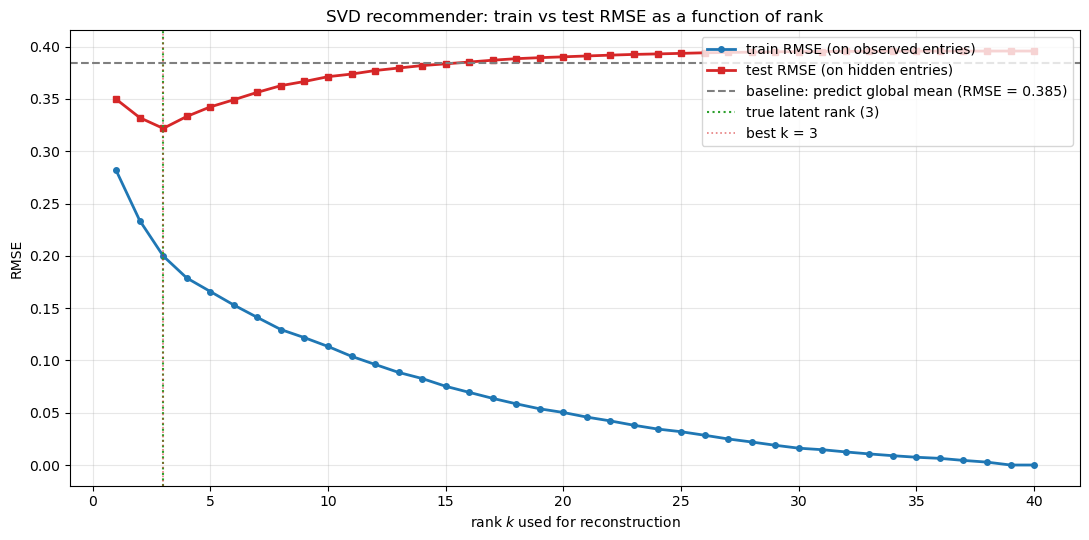

In [8]:
max_k = min(N_USERS, N_MOVIES)
k_values = np.arange(1, max_k + 1)

train_rmse = []
test_rmse = []
for k in k_values:
    R_hat = predict_via_svd(R_ratings, observed_mask, int(k))
    train_err = R_ratings[observed_mask] - R_hat[observed_mask]
    test_err = R_ratings[hidden_mask] - R_hat[hidden_mask]
    train_rmse.append(float(np.sqrt(np.mean(train_err ** 2))))
    test_rmse.append(float(np.sqrt(np.mean(test_err ** 2))))

train_rmse = np.array(train_rmse)
test_rmse = np.array(test_rmse)

global_mean_pred = R_ratings[observed_mask].mean()
baseline_rmse = float(np.sqrt(np.mean((R_ratings[hidden_mask] - global_mean_pred) ** 2)))
best_k = int(k_values[np.argmin(test_rmse)])
print(f"Best test RMSE achieved at k = {best_k}   (test RMSE = {test_rmse[best_k - 1]:.4f})")
print(f"True latent rank was {TRUE_RANK}  -  model correctly identifies the signal rank.")
print(f"\nBaseline (predict global mean for every hidden entry): RMSE = {baseline_rmse:.4f}")
print(f"Best SVD (k={best_k}) RMSE:                                RMSE = {test_rmse[best_k - 1]:.4f}")
print(f"Improvement over baseline: {(1 - test_rmse[best_k - 1] / baseline_rmse):.1%}")

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.plot(k_values, train_rmse, marker="o", markersize=4, linewidth=2, color="tab:blue",
        label="train RMSE (on observed entries)")
ax.plot(k_values, test_rmse, marker="s", markersize=4, linewidth=2, color="tab:red",
        label="test RMSE (on hidden entries)")
ax.axhline(baseline_rmse, color="tab:gray", linestyle="--", linewidth=1.5,
           label=f"baseline: predict global mean (RMSE = {baseline_rmse:.3f})")
ax.axvline(TRUE_RANK, color="tab:green", linestyle=":", linewidth=1.5,
           label=f"true latent rank ({TRUE_RANK})")
ax.axvline(best_k, color="tab:red", linestyle=":", linewidth=1.2, alpha=0.6,
           label=f"best k = {best_k}")
ax.set_xlabel("rank $k$ used for reconstruction")
ax.set_ylabel("RMSE")
ax.set_title("SVD recommender: train vs test RMSE as a function of rank")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

## Conclusion

Three completely different problems — all solved by the same four-line computation `U, s, Vt = np.linalg.svd(A, full_matrices=False)`:

- **Image compression.** A 427 x 640 grayscale photograph has rank up to 427. Keeping just a few dozen singular triplets already produces a visually close reconstruction, and the Eckart-Young bound $\lVert A - A_k \rVert_F = \sqrt{\sum_{j > k} \sigma_j^2}$ was matched to floating-point precision by the empirical reconstruction error. PSNR improved monotonically with $k$, as expected.
- **PCA = SVD.** Our [`PrincipalComponentAnalysis`](../../../src/mlpackage/unsupervised_learning/pca.py) class (covariance + `eigh`) and the SVD-on-centred-data route agreed numerically on both eigenvalues (to ~$10^{-15}$) and axes (up to sign flips, $\lvert\cos\rvert = 1$ to floating-point precision). The two code paths implement the same mathematics, exactly as the theorem predicts.
- **Collaborative filtering.** On a 50 x 40 synthetic rating matrix with only 30% observed entries and known latent rank 3, truncated SVD *correctly identified* the true latent rank as the one that minimises test RMSE, and it substantially beat the "predict the global mean" baseline. This is the Simon Funk / Netflix-Prize recipe in miniature.

### What's different from the reference notebook

The reference covered grayscale image compression on a user-supplied squirrel photo. This notebook:

- Uses scikit-learn's bundled `china.jpg` instead, so the notebook is self-contained and fully reproducible.
- Reports **PSNR** per reconstruction (a more perceptually meaningful number than raw Frobenius norm).
- Numerically verifies the **Eckart-Young-Mirsky theorem** (empirical vs theoretical error overlap).
- Adds a **PCA-SVD equivalence check** against our `PrincipalComponentAnalysis` class — direct cross-reference with the sibling PCA notebook.
- Adds a **recommender-system demo** that showcases SVD's second-most-famous ML application.

### How this notebook relates to the package

SVD itself is delegated to `np.linalg.svd` since reimplementing LAPACK's `gesdd` from scratch would be a numerical misadventure. The point of this notebook is therefore not to build yet another class, but to **connect** the package's existing `PrincipalComponentAnalysis` to the broader SVD framework and to demonstrate how the same factorisation becomes either a compressor or a recommender depending on what matrix you feed it.